# Data Augmented Classification

In [35]:
!python -m pip install transformers[torch]==4.40 datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 10.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 8.5 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.5/239.5 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.3/124.3 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.6/301.6 kB 40.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.6.0
    Uninstalling fsspec-2024.6.0:
      Successfully uninstalled fsspec-2024.6.0


In [1]:
import re

from datasets import Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer, set_seed
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

## Prerequisites

In [2]:
set_seed(42)

In [3]:
CLEANED_TWEET_FILE="../train_tweets.tsv"
CLEANED_ANNOTATION_FILE="../train_spans_norm.tsv"

In [4]:
tweet_df =  pd.read_csv(CLEANED_TWEET_FILE, sep='\t',
                        header=None, names=['id', 'tweet'],
                        dtype="string")
annotation_df = pd.read_csv(CLEANED_ANNOTATION_FILE, sep='\t',
                            header=None,
                            names=['id', 'cat', 'start', 'end', 'text', 'ptid'],
                            dtype={'id': "string", 'cat':"string", 'text':"string"})

In [5]:
tweet_df["class"] = tweet_df["id"].isin(annotation_df["id"])
tweet_df['class'] = tweet_df['class'].astype(int)

In [6]:
xtrain, xvalid, = train_test_split(tweet_df, stratify=tweet_df["class"], 
                                                  random_state=42, 
                                                  test_size=0.2, shuffle=True)

### NTCIR Data

In [7]:
aug_df = pd.read_csv("../ntcir17_mednlp-sc_sm_en_train_26_06_23.csv")

In [8]:
ade_columns = ['C0027497:nausea', 'C0011991:diarrhea',
       'C0015672:fatigue', 'C0042963:vomiting', 'C0003123:loss of appetite',
       'C0018681:headache', 'C0015967:fever',
       'C0206062:interstitial lung disease', 'C0023895:liver damage',
       'C0012833:dizziness', 'C0030193:pain', 'C0002170:alopecia',
       'C0004096:analgesic asthma syndrome', 'C0022658:renal impairment',
       'C0020517:hypersensitivity', 'C0917801:insomnia',
       'C0009806:constipation', 'C0005956:bone marrow dysfunction',
       'C0000737:abdominal pain', 'C0010692:hemorrhagic cystitis',
       'C0015230:rash', 'C0149745:stomatitis']

In [9]:
aug_df["class"] = aug_df[aug_df[ade_columns] > 0].any(axis='columns')
aug_df["class"] = aug_df["class"].astype(int)

In [10]:
aug_df.rename(columns={"text": "tweet"}, inplace=True)

### Base Model

In [11]:
model_checkpoint = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Preprocessing

In [12]:
def preprocess_data(examples):
    encoding = tokenizer(examples["tweet"], padding="max_length", truncation=True, max_length=512)
    encoding["labels"] = examples["class"]
    return encoding

### Metrics

In [13]:
def compute_metrics(p):
    preds = p.predictions[0] if isinstance(p.predictions,
            tuple) else p.predictions
    y_pred = np.argmax(preds, axis=1)
    return {'f1': f1_score(p.label_ids, y_pred)}

### Training Args

In [14]:
batch_size = 32
args = TrainingArguments(
    f"clf_exp",
    overwrite_output_dir=True,
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=3,
    #gradient_accumulation_steps=4,
    #gradient_checkpointing=True,
    fp16=True,
    #push_to_hub=True,
)

## Raw Data without Augmentation

In [15]:
xtrain_ds = xtrain[["tweet", "class"]].copy()
ds = Dataset.from_pandas(xtrain_ds, preserve_index=False)
train_dataset = ds.map(preprocess_data, batched=True, remove_columns=ds.column_names)
train_dataset.set_format("torch")

valid_ds = Dataset.from_pandas(xvalid, preserve_index=False)
valid_dataset = valid_ds.map(preprocess_data, batched=True, remove_columns=valid_ds.column_names)
valid_dataset.set_format("torch")

Map:   0%|          | 0/13752 [00:00<?, ? examples/s]

Map:   0%|          | 0/3438 [00:00<?, ? examples/s]

### Classification

In [16]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,No log,0.159972,0.597403
2,0.169900,0.132240,0.668008
3,0.098100,0.183268,0.679325
4,0.061700,0.184493,0.721116
5,0.035000,0.224838,0.692784
6,0.025000,0.239061,0.696177
7,0.012800,0.314613,0.697872
8,0.012800,0.318374,0.701403
9,0.012100,0.335184,0.697095
10,0.007100,0.361077,0.678112


TrainOutput(global_step=8600, training_loss=0.026458244183246955, metrics={'train_runtime': 4877.5382, 'train_samples_per_second': 56.389, 'train_steps_per_second': 1.763, 'total_flos': 7.23660646662144e+16, 'train_loss': 0.026458244183246955, 'epoch': 20.0})

In [17]:
raw_history = trainer.state.log_history

In [18]:
! rm -rf clf_exp

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Augmented Data without preprocessing

In [19]:
final = pd.concat([xtrain[["tweet", "class"]], aug_df[["tweet", "class"]]])
xtrain_ds = final.sample(frac=1).reset_index(drop=True)

In [20]:
ds = Dataset.from_pandas(xtrain_ds, preserve_index=False)
train_dataset = ds.map(preprocess_data, batched=True, remove_columns=ds.column_names)
train_dataset.set_format("torch")

Map:   0%|          | 0/21716 [00:00<?, ? examples/s]

In [21]:
valid_ds = Dataset.from_pandas(xvalid, preserve_index=False)
valid_dataset = valid_ds.map(preprocess_data, batched=True, remove_columns=valid_ds.column_names)
valid_dataset.set_format("torch")

Map:   0%|          | 0/3438 [00:00<?, ? examples/s]

### Classification

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)
trainer = Trainer(
    model,
    args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.258400,0.135966,0.655518
2,0.173300,0.118478,0.701245
3,0.114100,0.126451,0.705411
4,0.086900,0.160595,0.712000
5,0.071400,0.219531,0.705155
6,0.049100,0.237219,0.688034
7,0.036200,0.237207,0.682713
8,0.031100,0.279003,0.659048
9,0.023400,0.306240,0.671024
10,0.016500,0.268054,0.661905


TrainOutput(global_step=13580, training_loss=0.044209531052411835, metrics={'train_runtime': 7474.9628, 'train_samples_per_second': 58.103, 'train_steps_per_second': 1.817, 'total_flos': 1.142743935639552e+17, 'train_loss': 0.044209531052411835, 'epoch': 20.0})

In [24]:
aug_raw_history = trainer.state.log_history

In [25]:
! rm -rf clf_exp

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Augmented Preprocessed

Special words are removed from the data

In [26]:
user_re = re.compile("(<user_name>)|(@USER_+)")
url_re = re.compile("(<url>)|(HTTPURL_+)")

In [27]:
preprocessed = final.copy()
preprocessed['tweet'] = preprocessed['tweet'].str.replace(user_re, '', regex=True)
preprocessed['tweet'] = preprocessed['tweet'].str.replace(url_re, '', regex=True)
xtrain_ds = preprocessed.sample(frac=1).reset_index(drop=True)

preprocessed_valid = xvalid.copy()
preprocessed_valid['tweet'] = preprocessed_valid['tweet'].str.replace(user_re, '', regex=True)
preprocessed_valid['tweet'] = preprocessed_valid['tweet'].str.replace(url_re, '', regex=True)

In [28]:
ds = Dataset.from_pandas(xtrain_ds, preserve_index=False)
train_dataset = ds.map(preprocess_data, batched=True, remove_columns=ds.column_names)
train_dataset.set_format("torch")

valid_ds = Dataset.from_pandas(preprocessed_valid, preserve_index=False)
valid_dataset = valid_ds.map(preprocess_data, batched=True, remove_columns=valid_ds.column_names)
valid_dataset.set_format("torch")

Map:   0%|          | 0/21716 [00:00<?, ? examples/s]

Map:   0%|          | 0/3438 [00:00<?, ? examples/s]

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)
trainer = Trainer(
    model,
    args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.255300,0.128098,0.645985
2,0.171800,0.146564,0.666667
3,0.112200,0.141637,0.672769
4,0.082100,0.195186,0.682119
5,0.070400,0.220964,0.700637
6,0.042300,0.270962,0.678748
7,0.035500,0.282653,0.689895
8,0.027300,0.267067,0.693387
9,0.022500,0.350531,0.660584
10,0.018600,0.342970,0.672606


TrainOutput(global_step=13580, training_loss=0.0420945205814884, metrics={'train_runtime': 7469.9493, 'train_samples_per_second': 58.142, 'train_steps_per_second': 1.818, 'total_flos': 1.142743935639552e+17, 'train_loss': 0.0420945205814884, 'epoch': 20.0})

In [ ]:
preprocessed_history = trainer.state.log_history

In [32]:
! rm -rf clf_exp

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Augmented Normalized

Special words from smm4h dataset are changed to ntcir words

In [33]:
user_re = re.compile("@USER_+")
url_re = re.compile("HTTPURL_+")

In [34]:
normalized = final.copy()
normalized['tweet'] = normalized['tweet'].str.replace(user_re, '<user_name>', regex=True)
normalized['tweet'] = normalized['tweet'].str.replace(url_re, '<url>', regex=True)
xtrain_ds = normalized.sample(frac=1).reset_index(drop=True)

normalized_valid = xvalid.copy()
normalized_valid['tweet'] = normalized_valid['tweet'].str.replace(user_re, '<user_name>', regex=True)
normalized_valid['tweet'] = normalized_valid['tweet'].str.replace(url_re, '<url>', regex=True)

In [35]:
ds = Dataset.from_pandas(xtrain_ds, preserve_index=False)
train_dataset = ds.map(preprocess_data, batched=True, remove_columns=ds.column_names)
train_dataset.set_format("torch")

valid_ds = Dataset.from_pandas(normalized_valid, preserve_index=False)
valid_dataset = valid_ds.map(preprocess_data, batched=True, remove_columns=valid_ds.column_names)
valid_dataset.set_format("torch")

Map:   0%|          | 0/21716 [00:00<?, ? examples/s]

Map:   0%|          | 0/3438 [00:00<?, ? examples/s]

### Classification

In [36]:
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)
trainer = Trainer(
    model,
    args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1
1,0.256100,0.132224,0.649485
2,0.173000,0.149181,0.666667
3,0.113800,0.142717,0.691489
4,0.085800,0.218716,0.667780
5,0.073200,0.198381,0.704846
6,0.044400,0.255680,0.694698
7,0.035400,0.238415,0.685841
8,0.027700,0.242119,0.671642
9,0.024100,0.306968,0.675000
10,0.019500,0.313352,0.685259


TrainOutput(global_step=13580, training_loss=0.04374494278948858, metrics={'train_runtime': 7465.2181, 'train_samples_per_second': 58.179, 'train_steps_per_second': 1.819, 'total_flos': 1.142743935639552e+17, 'train_loss': 0.04374494278948858, 'epoch': 20.0})

In [37]:
normalized_history = trainer.state.log_history

In [38]:
! rm -rf clf_exp

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Plot Eval

In [39]:
x, y_raw = zip(*[(step['epoch'], step['eval_f1']) for step in raw_history if 'eval_f1' in step])

In [40]:
x, y_aug = zip(*[(step['epoch'], step['eval_f1']) for step in aug_raw_history if 'eval_f1' in step])

In [41]:
_, y_prep = zip(*[(step['epoch'], step['eval_f1']) for step in preprocessed_history if 'eval_f1' in step])

In [42]:
_, y_norm = zip(*[(step['epoch'], step['eval_f1']) for step in normalized_history if 'eval_f1' in step])

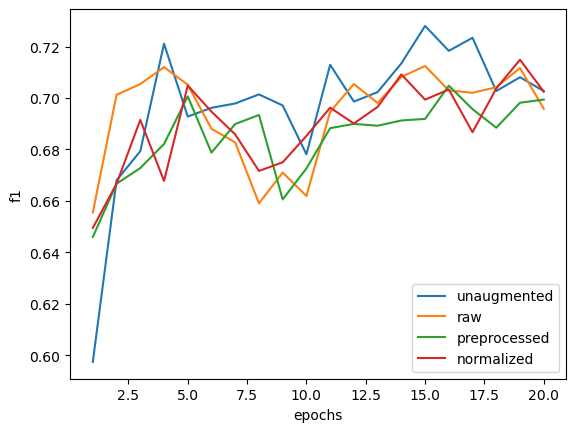

In [43]:
plt.plot(x, y_raw, label='unaugmented')
plt.plot(x, y_aug, label='raw')
plt.plot(x, y_prep, label='preprocessed')
plt.plot(x, y_norm, label='normalized')
plt.xlabel('epochs')
plt.ylabel('f1')
plt.legend()

In [44]:
plt.savefig('eval2.png')

<Figure size 640x480 with 0 Axes>